<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/PML/Day_23_11_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔰Random Forest🔰

In [10]:
from google.colab import drive
drive.mount('/content/drive')


import numpy as np
import pandas as pd

import os
os.chdir('/content/drive/MyDrive/CDAC/')

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy import random
from collections import Counter

from numpy.linalg import inv
from numpy.linalg import eig

import matplotlib
from matplotlib import pyplot as plt

import seaborn as sns

import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy.stats import chisquare
from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f
from sklearn.metrics import mean_squared_error

from sklearn.metrics import roc_auc_score

#========================================================================

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.discrete.discrete_model import MNLogit

import sklearn
from sklearn.model_selection import train_test_split



import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#   this will give the area of the left side we want the area of the right side so we do the 1 -
1 - binom.cdf(7,15,0.7)

np.float64(0.9499874599462239)

In [8]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]

diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df = df.drop('DietType', axis=1)
df = pd.concat([df,diet_dummy], axis=1)

x= df.drop('Outcome', axis=1)  # column of predictors
y= df.Outcome   # column of response

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

y_pred=dtc.predict(x_test)
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

# hyperparameter tuning

param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [2,3,4,5]
}

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

dtc = DecisionTreeClassifier(criterion= 'gini',
 max_depth= 5,
 max_features= 'sqrt',
 min_samples_leaf= 5,
 min_samples_split= 2,
 splitter= 'best')

dtc.fit(x_train,y_train)
print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

y_pred = dtc.predict(x_test)
print(confusion_matrix(y_test,y_pred))

[[83 18]
 [15 38]]
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       101
           1       0.68      0.72      0.70        53

    accuracy                           0.79       154
   macro avg       0.76      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154

1.0
0.7857142857142857
0.8664495114006515
0.8376623376623377
[[92  9]
 [16 37]]


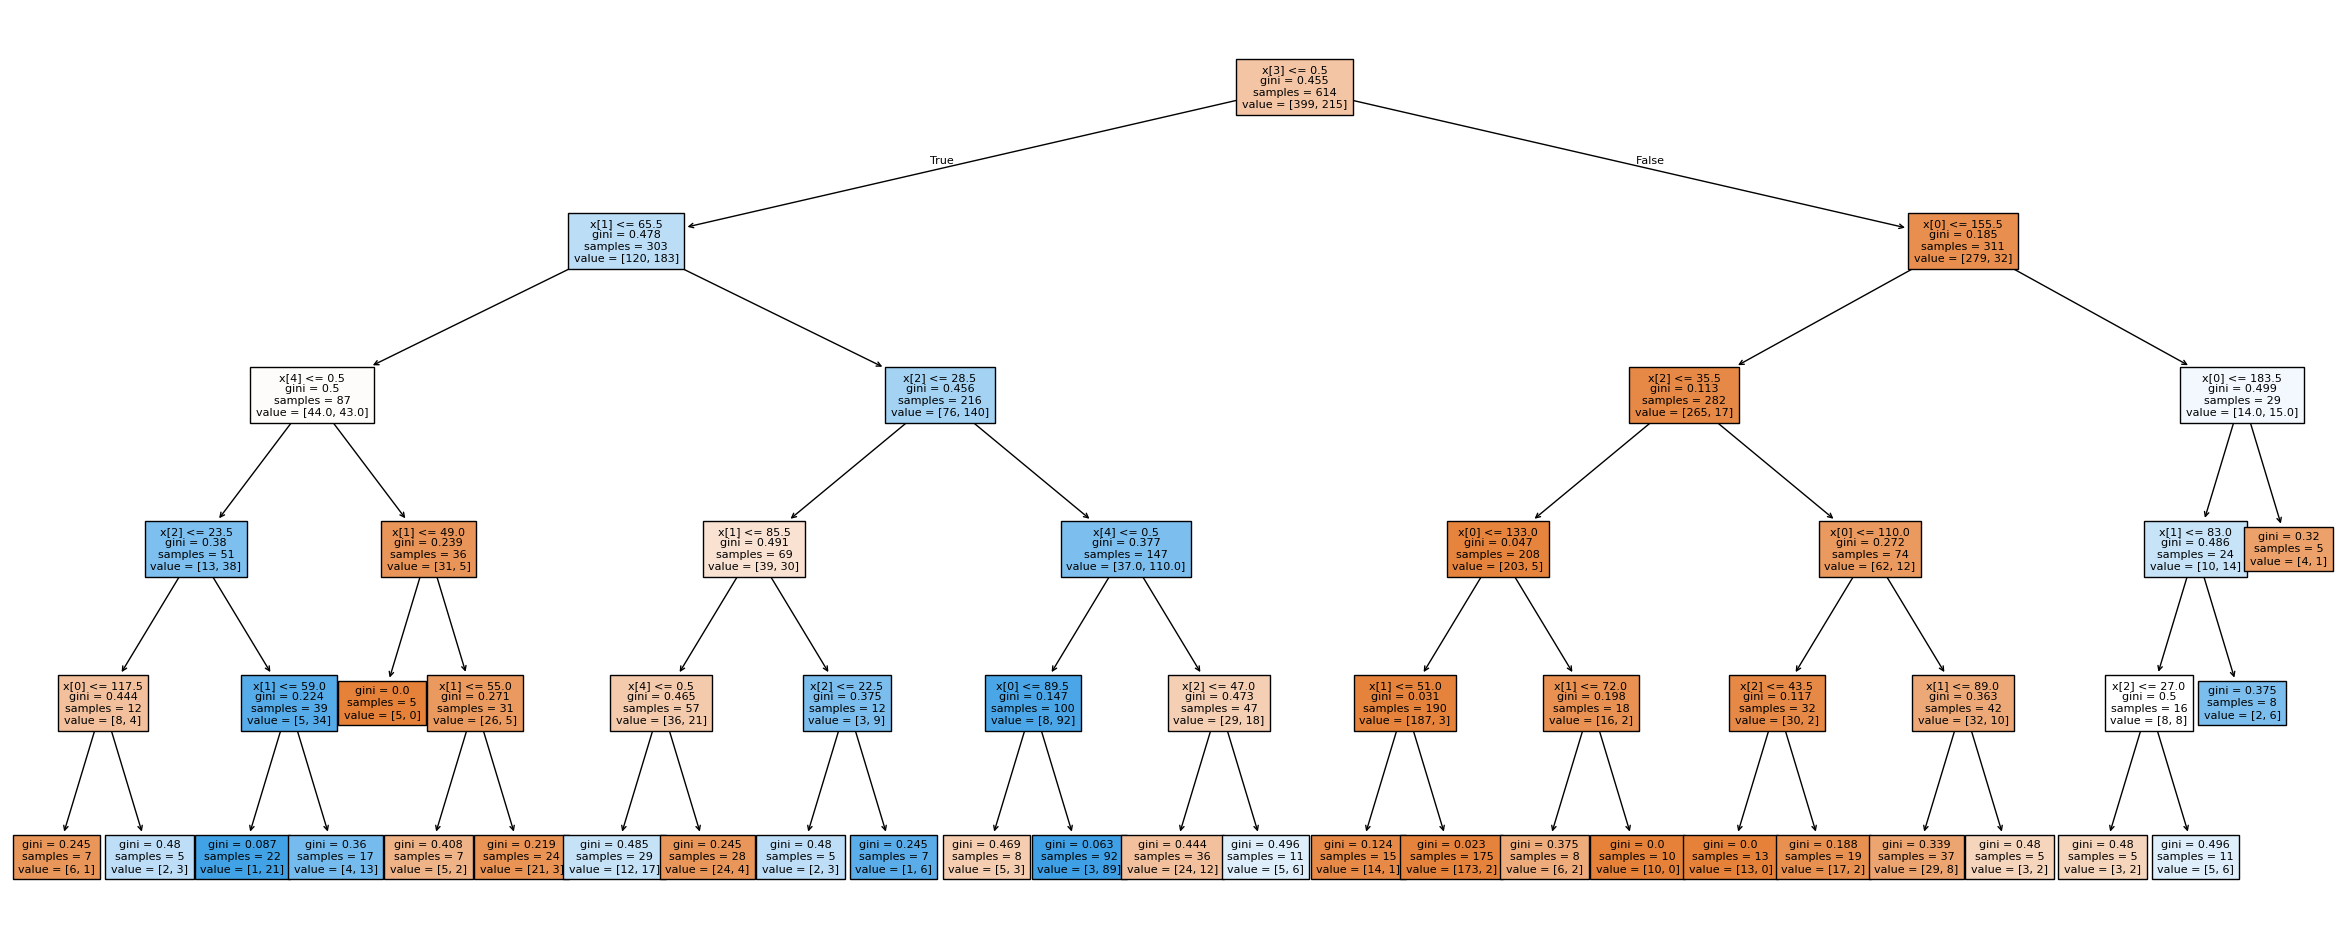

In [14]:
plt.figure(figsize=(30, 12))
tree.plot_tree( dtc,filled=True,fontsize=8 )  # increase text size
plt.show()

# 🔰Random Forest(N* Decision Tree)🔰

- #### the random forest would be the group of the x number of decision trees
- #### the decision in random forest are taken by the rule of majority
#### in categorical rule of majority(mode)
#### continuous the average will taken.
- #### the random forest will have all the hyperparameter of decision tree plus one more n_estimators.
---
#### The decision tree are less prone to outliers.

- the first the decision tree in series of the boosting model called as weak learner.
- the last the decision tree in series of the boosting model called as strong learner.(because that model is elarn from the mistakes)